In [1]:
def nlp_pipeline_demo():
    raw_text = "이 영화는 정말 재미있어요. 배우들 연기가 좋습니다."
    tokens = ["이", "영화는", "정말", "재미있어요", ".", "배우들", "연기가", "좋습니다", "."]
    cleaned = ["영화", "정말", "재미있어요", "배우들", "연기가", "좋습니다"] # 정제 / 불용어 제거
    vectorized = [45, 123, 892, 156, 234, 567]
    prediction = {"감정": "긍정", "확률": 0.94} # self attention / 모델에 넣으면 결과가 이처럼 나옴
    print(prediction)

nlp_pipeline_demo()

{'감정': '긍정', '확률': 0.94}


In [2]:
import random
from collections import Counter

class BusinessSentimentAnalyzer:
    def __init__(self): # 불균형 데이터가 대부분이기 때문데 딥러닝에선 크게 소용없음
        self.positive_keywords = ["좋", "훌륭", "대박", "강추", "꿀템", "만족"]
        self.negative_keywords = ["나쁘", "별로", "짜증", "실망", "최악", "환불"]

    def analyze_sentiment(self, text):
        positive_count = sum(1 for word in self.positive_keywords if word in text)
        negative_count = sum(1 for word in self.negative_keywords if word in text)

        if positive_count > negative_count:
            sentiment = "긍정"
            confidence = min(0.9, 0.6 + positive_count * 0.1)
            action = self._get_positive_action(text)
        elif negative_count > positive_count:
            sentiment = "부정"
            confidence = min(0.9, 0.6 + negative_count * 0.1)
            action = self._get_negative_action(text)
        else:
            sentiment = "중립"
            confidence = 0.5
            action = "개선 포인트 분석"
        return {"sentiment": sentiment,
                "confidence": confidence,
                "action": action,
                "priority": self._get_priority(sentiment, confidence)}

    def _get_positive_action(self, text):
        if any(word in text for word in ["강추", "추천", "꿀템"]):
            return "마케팅 자료로 활용(베스트 리뷰)"
        elif any(word in text for word in ["품질", "좋네요"]):
            return "품질 만족도 데이터 수집"
        else:
            return "고객 만족도 향상 요인 분석"

    def _get_negative_action(self, text):
        if any(word in text for word in ["배송", "늦어요"]):
            return "물류팀 우선 처리 (배송 개선)"
        elif any(word in text for word in ["품질", "별로"]):
            return "품질 관리팀 검토 필요"
        elif any(word in text for word in ["서비스", "직원"]):
            return "고객 서비스팀 교육 강화"
        else:
            return "고객 서비스팀 우선 처리"

    def _get_priority(self, sentiment, confidence):
        if sentiment == "부정" and confidence > 0.8:
            return "긴급"
        elif sentiment == "부정":
            return "높음"
        elif sentiment == "긍정" and confidence > 0.8:
            return "활용"
        else:
            return "모니터링"

def business_sentiment_demo():
    analyzer = BusinessSentimentAnalyzer()
    reviews = ["배송이 너무 늦어요, 짜증납니다.",
               "제품 품질이 생각보다 좋네요.",
               "그냥 그래요. 딱히 나쁘지도 좋지도 않아요.",
               "와! 이거 완전 꿀템이다. 강추강추!!",
               "고객서비스 직원이 너무 불친절해요.",
               "빠른 배송에 만족합니다. 품질도 훌륭해요"]

    results = []

    for i, review in enumerate(reviews, 1):
        result = analyzer.analyze_sentiment(review)
        results.append(result)
        print(review)
        print(result["sentiment"])
        print(result["confidence"])
        print(result["action"])
        print(result["priority"])
    sentiments = [r["sentiment"] for r in results]
    sentiment_stats = Counter(sentiments)
    print(sentiment_stats["긍정"])
    print(sentiment_stats["부정"])
    print(sentiment_stats["중립"])

    urgent_items = [r for r in results if "긴급" in r["priority"]]
    high_items = [r for r in results if "높음" in r["priority"]]
    print(len(urgent_items))
    print(len(high_items))

    actions = [r["action"] for r in results]
    department_actions = Counter(actions)

    for action, count in department_actions.items():
        print(action, count)

def real_time_monitoring_demo():
    analyzer = BusinessSentimentAnalyzer()
    streaming_reviews = ["주문한 상품이 빨리 왔어요.",
                        "포장이 너무 엉성해요.",
                        "가격 대비 만족스러운 품질",
                        "교환 요청했는데, 처리가 늦어요.",
                        "이런 제품 찾고 있었는데 딱이에요"]
    import time
    for review in streaming_reviews:
        result = analyzer.analyze_sentiment(review)
        if "긴급" in result["priority"]:
            print("긴급 알림")
        elif "높음" in result["priority"]:
            print("우선 처리")
        else:
            print("일반")
    time.sleep(1)

business_sentiment_demo()
real_time_monitoring_demo()

배송이 너무 늦어요, 짜증납니다.
부정
0.7
물류팀 우선 처리 (배송 개선)
높음
제품 품질이 생각보다 좋네요.
긍정
0.7
품질 만족도 데이터 수집
모니터링
그냥 그래요. 딱히 나쁘지도 좋지도 않아요.
중립
0.5
개선 포인트 분석
모니터링
와! 이거 완전 꿀템이다. 강추강추!!
긍정
0.8
마케팅 자료로 활용(베스트 리뷰)
모니터링
고객서비스 직원이 너무 불친절해요.
중립
0.5
개선 포인트 분석
모니터링
빠른 배송에 만족합니다. 품질도 훌륭해요
긍정
0.8
품질 만족도 데이터 수집
모니터링
3
1
2
0
1
물류팀 우선 처리 (배송 개선) 1
품질 만족도 데이터 수집 2
개선 포인트 분석 2
마케팅 자료로 활용(베스트 리뷰) 1
일반
일반
일반
일반
일반


In [3]:
# LSTM 게이트
# LSTM 감성 분석기 생성
import torch
from torch.nn.utils.rnn import pad_sequence

x_train_seq = [torch.tensor([1, 5, 23, 67, 89, 34]),
               torch.tensor([45, 78, 12, 34]),
               torch.tensor([1, 5, 23, 67]),
               torch.tensor([45, 78, 12, 34, 90])]
y_train = torch.tensor([1, 0, 1, 0])

x_train = pad_sequence(x_train_seq, batch_first = True, padding_value = 0)
print(x_train.shape)

torch.Size([4, 6])


In [5]:
import torch.nn as nn

class SentimentLSTM(nn.Module):
    def __init__(self,
                 vocab_size,
                 embedding_dim,
                 hidden_dim,
                 output_dim,
                 n_layers = 1,
                 dropout = 0.5):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size,
                                      embedding_dim,
                                      padding_idx = 0)
        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers = n_layers,
                            batch_first = True,
                            dropout = dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        lstm_out, (hidden, cell) = self.lstm(embedded)
        final_feature = hidden[-1]
        output = self.fc(final_feature)
        return output

vocab_size = 5000
embedding_dim = 100
hidden_dim = 128
output_dim = 2

model_lstm = SentimentLSTM(vocab_size,
                           embedding_dim,
                           hidden_dim,
                           output_dim,
                           n_layers = 2,
                           dropout = 0.3)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr = 0.001)
print(model_lstm)

SentimentLSTM(
  (embedding): Embedding(5000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [7]:
# 학습과 평가

num_epochs = 5
for epoch in range(num_epochs):
    model_lstm.train()
    total_loss = 0.0
    for batch_x, batch_y in [(x_train, y_train)]:
        optimizer.zero_grad()
        outputs = model_lstm(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / 1 # batch_size가 1이기 때문에 dataloader 사용하지 않았기때문
    print(avg_loss)

model_lstm.eval()
with torch.no_grad():
    outputs = model_lstm(x_train)
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == y_train).sum().item()
    accuracy = 100 * correct / y_train.size(0)
print(accuracy)

0.5894709229469299
0.5459583401679993
0.4958479702472687
0.4432453513145447
0.3872320353984833
100.0


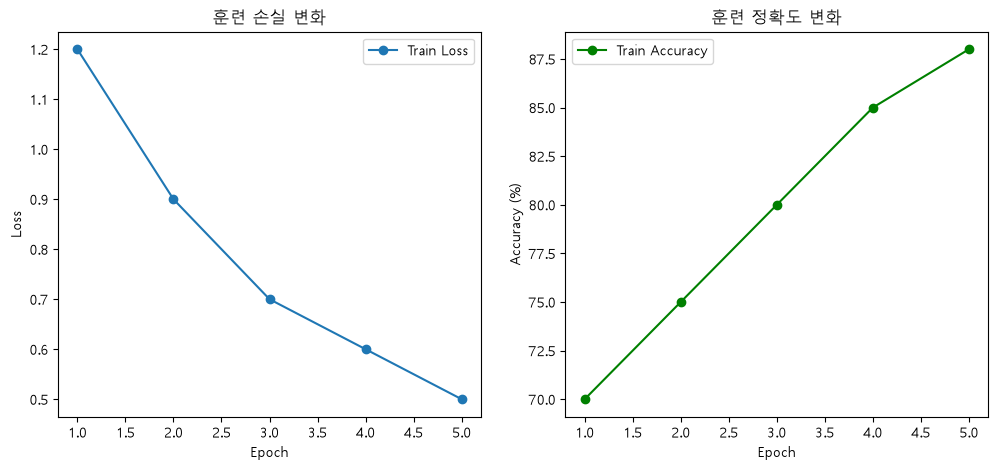

In [9]:
#학습 과정 시각화 및 하이퍼파라미터 조정
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False

# 예시: 학습 과정 동안 손실과 정확도를 기록했다고 가정
epochs = [1, 2, 3, 4, 5]
train_loss = [1.2, 0.9, 0.7, 0.6, 0.5]  # 가상 데이터
train_accuracy = [70, 75, 80, 85, 88]     # 가상 데이터

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('훈련 손실 변화')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy, marker='o', label='Train Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('훈련 정확도 변화')
plt.legend()
plt.show()

In [10]:
# 기계 번역 seq2seq
import torch
import torch.nn as nn
import torch.optim as optim

class Encoder(nn.Module):
    def __init__(self,
                 input_dim,
                 emb_dim,
                 hidden_dim,
                 n_layers = 1):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim,
                            hidden_dim,
                            n_layers,
                            batch_first = True)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, (hidden, cell)

class Decoder(nn.Module):
    def __init__(self,
                 output_dim,
                 emb_dim,
                 hidden_dim,
                 n_layers = 1):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim,
                            hidden_dim,
                            n_layers,
                            batch_first = True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, trg, hidden, cell):
        trg = trg.unsqueeze(1)
        embedded = self.embedding(trg)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.fc_out(output.squeeze(1))
        return prediction, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio = 0.5):
        batch_size = src.size(0)
        trg_len = trg.size(1)
        output_dim = self.decoder.fc_out.out_features
        outputs = torch.zeros(batch_size, trg_len, output_dim).to(self.device)
        enc_outputs, (hidden, cell) = self.encoder(src)
        input = trg[:, 0]
        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[:, t, :] = output
            teacher_force = torch.rand(1).item() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = trg[:, t] if teacher_force else top1
        return outputs

SRC_VOCAB_SIZE = 5000
TRG_VOCAB_SIZE = 5000
EMB_DIM = 256
HIDDEN_DIM = 512
N_LAYERS = 1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

encoder = Encoder(SRC_VOCAB_SIZE, EMB_DIM, HIDDEN_DIM, N_LAYERS)
decoder = Decoder(TRG_VOCAB_SIZE, EMB_DIM, HIDDEN_DIM, N_LAYERS)
model_seq2seq = Seq2Seq(encoder, decoder, device).to(device)
optimizer_seq2seq = optim.Adam(model_seq2seq.parameters(), lr = 0.001)
criterion_seq2seq = nn.CrossEntropyLoss(ignore_index = 0)

src_example = torch.randint(1, SRC_VOCAB_SIZE, (32, 10)).to(device)
trg_example = torch.randint(1, TRG_VOCAB_SIZE, (32, 12)).to(device)

model_seq2seq.train()
optimizer_seq2seq.zero_grad()
output_seq = model_seq2seq(src_example, trg_example)

output_dim = output_seq.shape[-1]
output_seq = output_seq[:, 1:, :].reshape(-1, output_dim)
trg_seq = trg_example[:, 1:].reshape(-1)
loss_seq = criterion_seq2seq(output_seq, trg_seq)
loss_seq.backward()
optimizer_seq2seq.step()
print(loss_seq.item())

8.521109580993652
